# Time Complexity and Execution Time Analysis

This notebook is the main analysis entrypoint for the execution-time experiment. It keeps the existing algorithm and utility modules, varies input size through stratified row subsampling, and keeps all dataset features available to the feature selection algorithms.

## 1. Imports and Experiment Constants

In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import issparse
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from algorithms.bga import binary_genetic_algorithm
from algorithms.bgwo import binary_grey_wolf_optimizer
from algorithms.bpso import binary_particle_swarm_optimization
from algorithms.bwoa import binary_whale_optimization_algorithm
from utils.data_loader import PreparedDataset, load_dataset
from utils.fitness import make_accuracy_function, make_fitness_function

DATASET_NAMES = ["madelon", "arcene", "dexter", "dorothea", "gisette"]
FRACTIONS = [0.2, 0.4, 0.6, 0.8, 1.0]
RANDOM_STATE = 42
POPULATION_SIZE = 10
ITERATIONS = 30
EARLY_STOPPING_PATIENCE = 5
MIN_DELTA = 0.001

RESULTS_DIR = Path("results") / "time_complexity_analysis"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

ALGORITHMS: dict[str, Callable[..., tuple[np.ndarray, float, list[float], bool]]] = {
    "BGA": binary_genetic_algorithm,
    "BPSO": binary_particle_swarm_optimization,
    "BGWO": binary_grey_wolf_optimizer,
    "BWOA": binary_whale_optimization_algorithm,
}

DATASET_CACHE: dict[str, tuple[np.ndarray, np.ndarray, np.ndarray]] = {}

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


## 2. Shared Helpers

In [2]:
def dataset_seed(dataset_name: str) -> int:
    return RANDOM_STATE + DATASET_NAMES.index(dataset_name) * 100000


def load_dataset_cached(dataset_name: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    normalized_name = dataset_name.lower()
    if normalized_name not in DATASET_CACHE:
        x, y, feature_names = load_dataset(normalized_name)
        if issparse(x):
            x = x.tocsr()
        DATASET_CACHE[normalized_name] = (x, y, feature_names)
    return DATASET_CACHE[normalized_name]


def matrix_nonzero_count(x: np.ndarray) -> int:
    if issparse(x):
        return int(x.nnz)
    return int(np.count_nonzero(x))


def matrix_density(x: np.ndarray) -> float:
    total_cells = x.shape[0] * x.shape[1]
    if total_cells == 0:
        return 0.0
    return matrix_nonzero_count(x) / total_cells


def class_distribution_text(y: np.ndarray) -> str:
    labels, counts = np.unique(y, return_counts=True)
    distribution = {str(label): int(count) for label, count in zip(labels, counts)}
    return json.dumps(distribution, sort_keys=True)


def build_dataset_summary(dataset_names: list[str] = DATASET_NAMES) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for dataset_name in dataset_names:
        x, y, _ = load_dataset_cached(dataset_name)
        rows.append(
            {
                "dataset": dataset_name,
                "rows": int(x.shape[0]),
                "features": int(x.shape[1]),
                "input_size": int(x.shape[0] * x.shape[1]),
                "format": "sparse" if issparse(x) else "dense",
                "nonzero_count": matrix_nonzero_count(x),
                "density": matrix_density(x),
                "class_distribution": class_distribution_text(y),
            }
        )
    return pd.DataFrame(rows)


def make_nested_stratified_subsets(
    y: np.ndarray,
    fractions: list[float] = FRACTIONS,
    random_state: int = RANDOM_STATE,
) -> dict[float, np.ndarray]:
    rng = np.random.default_rng(random_state)
    shuffled_by_class: dict[object, np.ndarray] = {}
    for label in np.unique(y):
        class_indices = np.flatnonzero(y == label)
        shuffled_by_class[label] = rng.permutation(class_indices)

    subsets: dict[float, np.ndarray] = {}
    for fraction in fractions:
        selected_parts: list[np.ndarray] = []
        for class_indices in shuffled_by_class.values():
            selected_count = int(round(len(class_indices) * fraction))
            selected_count = max(1, min(selected_count, len(class_indices)))
            selected_parts.append(class_indices[:selected_count])
        selected_indices = np.concatenate(selected_parts)
        selected_indices.sort()
        subsets[fraction] = selected_indices
    return subsets


def build_subsample_summary(dataset_name: str) -> pd.DataFrame:
    x, y, _ = load_dataset_cached(dataset_name)
    subsets = make_nested_stratified_subsets(y, random_state=dataset_seed(dataset_name))
    rows: list[dict[str, object]] = []
    for fraction, indices in subsets.items():
        subset_x = x[indices]
        subset_y = y[indices]
        rows.append(
            {
                "dataset": dataset_name,
                "fraction": fraction,
                "rows": int(subset_x.shape[0]),
                "features": int(subset_x.shape[1]),
                "input_size": int(subset_x.shape[0] * subset_x.shape[1]),
                "nonzero_count": matrix_nonzero_count(subset_x),
                "density": matrix_density(subset_x),
                "class_distribution": class_distribution_text(subset_y),
            }
        )
    return pd.DataFrame(rows)


def prepare_subset_dataset(dataset_name: str, indices: np.ndarray, random_state: int) -> PreparedDataset:
    x, y, feature_names = load_dataset_cached(dataset_name)
    subset_x = x[indices]
    subset_y = y[indices]

    x_train_validation, x_test, y_train_validation, y_test = train_test_split(
        subset_x,
        subset_y,
        test_size=0.20,
        random_state=random_state,
        stratify=subset_y,
    )
    x_train, x_validation, y_train, y_validation = train_test_split(
        x_train_validation,
        y_train_validation,
        test_size=0.25,
        random_state=random_state + 1,
        stratify=y_train_validation,
    )

    scaler = StandardScaler(with_mean=not issparse(x_train))
    x_train = scaler.fit_transform(x_train)
    x_validation = scaler.transform(x_validation)
    x_test = scaler.transform(x_test)

    return PreparedDataset(
        dataset_name=dataset_name,
        input_features=int(subset_x.shape[1]),
        x_train=x_train,
        x_validation=x_validation,
        x_test=x_test,
        y_train=y_train,
        y_validation=y_validation,
        y_test=y_test,
        feature_names=feature_names,
    )


## 3. Dataset Shape Summary

Run this before the algorithm experiments. The `input_size` column is `rows * features`, while `nonzero_count` and `density` help explain sparse datasets where rectangular input size alone may not predict runtime.

In [3]:
dataset_summary = build_dataset_summary()
dataset_summary.to_csv(RESULTS_DIR / "dataset_summary.csv", index=False)
display(dataset_summary)


,dataset,rows,features,input_size,format,nonzero_count,density,class_distribution
0,madelon,2600,500,1300000,dense,1299999,0.999999,"{""1"": 1300, ""2"": 1300}"
1,arcene,200,10000,2000000,dense,1087539,0.543770,"{""1"": 88, ""2"": 112}"
2,dexter,600,20000,12000000,sparse,56167,0.004681,"{""0"": 300, ""1"": 300}"
3,dorothea,1150,100000,115000000,sparse,1045512,0.009091,"{""0"": 1038, ""1"": 112}"
4,gisette,7000,5000,35000000,sparse,34700997,0.991457,"{""-1"": 3500, ""1"": 3500}"


## 4. Full-Dataset Linear SVM Training Time

This measures one full-feature evaluator-model training run per dataset. The metaheuristic runtime below is still the main execution-time result, but this table helps explain whether repeated SVM training inside the fitness function is likely to dominate runtime.

In [4]:
def time_full_dataset_svm_training(dataset_names: list[str] = DATASET_NAMES) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for dataset_name in dataset_names:
        x, y, _ = load_dataset_cached(dataset_name)
        seed = dataset_seed(dataset_name)
        x_train, _, y_train, _ = train_test_split(
            x,
            y,
            test_size=0.40,
            random_state=seed,
            stratify=y,
        )
        scaler = StandardScaler(with_mean=not issparse(x_train))
        x_train = scaler.fit_transform(x_train)
        model = SGDClassifier(
            loss="hinge",
            alpha=0.0001,
            max_iter=1000,
            tol=1e-3,
            random_state=42,
        )
        start = time.perf_counter()
        model.fit(x_train, y_train)
        training_time_seconds = time.perf_counter() - start
        rows.append(
            {
                "dataset": dataset_name,
                "train_rows": int(x_train.shape[0]),
                "features": int(x_train.shape[1]),
                "train_input_size": int(x_train.shape[0] * x_train.shape[1]),
                "training_time_seconds": training_time_seconds,
            }
        )
    return pd.DataFrame(rows)


svm_training_times = time_full_dataset_svm_training()
svm_training_times.to_csv(RESULTS_DIR / "full_dataset_svm_training_times.csv", index=False)
display(svm_training_times)


,dataset,train_rows,features,train_input_size,training_time_seconds
0,madelon,1560,500,780000,0.161616
1,arcene,120,10000,1200000,0.337110
2,dexter,360,20000,7200000,0.013453
3,dorothea,690,100000,69000000,0.172650
4,gisette,4200,5000,21000000,17.717211


## 5. Runtime Experiment Helpers

In [5]:
def run_single_algorithm_for_subset(
    dataset_name: str,
    fraction: float,
    subset_indices: np.ndarray,
    algorithm_name: str,
    algorithm_fn: Callable[..., tuple[np.ndarray, float, list[float], bool]],
    fraction_index: int,
    algorithm_index: int,
) -> dict[str, object]:
    seed = dataset_seed(dataset_name) + fraction_index * 1000 + algorithm_index
    prepared_dataset = prepare_subset_dataset(dataset_name, subset_indices, seed)
    rng = np.random.default_rng(seed)

    fitness_fn, validation_accuracy_fn = make_fitness_function(
        prepared_dataset.x_train,
        prepared_dataset.x_validation,
        prepared_dataset.y_train,
        prepared_dataset.y_validation,
        rng,
    )

    print(f"Running {algorithm_name} on {dataset_name}, fraction={fraction:.1f}, rows={len(subset_indices)}")
    start = time.perf_counter()
    best_mask, best_fitness, convergence_history, stopped_early = algorithm_fn(
        prepared_dataset.input_features,
        fitness_fn,
        rng,
        POPULATION_SIZE,
        ITERATIONS,
        progress_callback=lambda iteration, score: print(
            f"  iteration {iteration}/{ITERATIONS}, best_fitness={score:.6f}",
            flush=True,
        ),
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        min_delta=MIN_DELTA,
    )
    runtime_seconds = time.perf_counter() - start

    validation_accuracy = validation_accuracy_fn(best_mask)
    test_accuracy_fn = make_accuracy_function(
        prepared_dataset.x_train,
        prepared_dataset.y_train,
        prepared_dataset.x_test,
        prepared_dataset.y_test,
        rng,
    )
    test_accuracy = test_accuracy_fn(best_mask)

    x, _, _ = load_dataset_cached(dataset_name)
    subset_x = x[subset_indices]

    return {
        "dataset": dataset_name,
        "algorithm": algorithm_name,
        "fraction": fraction,
        "rows": int(subset_x.shape[0]),
        "features": int(subset_x.shape[1]),
        "input_size": int(subset_x.shape[0] * subset_x.shape[1]),
        "nonzero_count": matrix_nonzero_count(subset_x),
        "density": matrix_density(subset_x),
        "runtime_seconds": runtime_seconds,
        "best_fitness": best_fitness,
        "validation_accuracy": validation_accuracy,
        "test_accuracy": test_accuracy,
        "selected_count": int(best_mask.sum()),
        "iterations_run": max(len(convergence_history) - 1, 0),
        "stopped_early": stopped_early,
    }


def run_dataset_scalability(dataset_name: str) -> pd.DataFrame:
    x, y, _ = load_dataset_cached(dataset_name)
    subsets = make_nested_stratified_subsets(y, random_state=dataset_seed(dataset_name))

    print(f"Class-ratio check for {dataset_name}")
    subsample_summary = build_subsample_summary(dataset_name)
    display(subsample_summary)
    subsample_summary.to_csv(RESULTS_DIR / f"{dataset_name}_subsample_summary.csv", index=False)

    result_rows: list[dict[str, object]] = []
    for fraction_index, (fraction, indices) in enumerate(subsets.items()):
        for algorithm_index, (algorithm_name, algorithm_fn) in enumerate(ALGORITHMS.items()):
            result = run_single_algorithm_for_subset(
                dataset_name,
                fraction,
                indices,
                algorithm_name,
                algorithm_fn,
                fraction_index,
                algorithm_index,
            )
            result_rows.append(result)
            pd.DataFrame(result_rows).to_csv(RESULTS_DIR / f"{dataset_name}_scalability_results.csv", index=False)
            print(
                f"  done: validation_accuracy={result['validation_accuracy']:.4f}, "
                f"test_accuracy={result['test_accuracy']:.4f}, "
                f"selected={result['selected_count']}, "
                f"runtime={result['runtime_seconds']:.4f}s",
                flush=True,
            )

    dataset_results = pd.DataFrame(result_rows)
    display(dataset_results)
    return dataset_results


## 6. Dataset Runs

Each dataset has its own cell. If a large dataset takes too long, completed dataset CSV files remain available under `results/time_complexity_analysis/`.

### Madelon

In [6]:
madelon_results = run_dataset_scalability("madelon")


Class-ratio check for madelon


,dataset,fraction,rows,features,input_size,nonzero_count,density,class_distribution
0,madelon,0.2,520,500,260000,260000,1.000000,"{""1"": 260, ""2"": 260}"
1,madelon,0.4,1040,500,520000,520000,1.000000,"{""1"": 520, ""2"": 520}"
2,madelon,0.6,1560,500,780000,780000,1.000000,"{""1"": 780, ""2"": 780}"
3,madelon,0.8,2080,500,1040000,1040000,1.000000,"{""1"": 1040, ""2"": 1040}"
4,madelon,1.0,2600,500,1300000,1299999,0.999999,"{""1"": 1300, ""2"": 1300}"


Running BGA on madelon, fraction=0.2, rows=520
  iteration 1/30, best_fitness=0.376130
  iteration 2/30, best_fitness=0.357032
  iteration 3/30, best_fitness=0.309555
  iteration 4/30, best_fitness=0.309555
  iteration 5/30, best_fitness=0.309555
  iteration 6/30, best_fitness=0.309555
  iteration 7/30, best_fitness=0.309555
  iteration 8/30, best_fitness=0.309555
  done: validation_accuracy=0.6923, test_accuracy=0.5192, selected=247, runtime=1.3373s
Running BPSO on madelon, fraction=0.2, rows=520
  iteration 1/30, best_fitness=0.385589
  iteration 2/30, best_fitness=0.385589
  iteration 3/30, best_fitness=0.385469
  iteration 4/30, best_fitness=0.385469
  iteration 5/30, best_fitness=0.385469
  iteration 6/30, best_fitness=0.357212
  iteration 7/30, best_fitness=0.357212
  iteration 8/30, best_fitness=0.357212
  iteration 9/30, best_fitness=0.357212
  iteration 10/30, best_fitness=0.357212
  iteration 11/30, best_fitness=0.357212
  done: validation_accuracy=0.6442, test_accuracy=0.480

,dataset,algorithm,fraction,rows,features,input_size,nonzero_count,density,runtime_seconds,best_fitness,validation_accuracy,test_accuracy,selected_count,iterations_run,stopped_early
0,madelon,BGA,0.2,520,500,260000,260000,1.000000,1.337305,0.309555,0.692308,0.519231,247,8,True
1,madelon,BPSO,0.2,520,500,260000,260000,1.000000,1.620423,0.357212,0.644231,0.480769,250,11,True
2,madelon,BGWO,0.2,520,500,260000,260000,1.000000,1.545802,0.377430,0.625000,0.519231,309,10,True
3,madelon,BWOA,0.2,520,500,260000,260000,1.000000,2.106988,0.300316,0.701923,0.471154,261,15,True
4,madelon,BGA,0.4,1040,500,520000,520000,1.000000,2.338229,0.371890,0.629808,0.495192,270,13,True
5,madelon,BPSO,0.4,1040,500,520000,520000,1.000000,1.504610,0.404728,0.596154,0.533654,246,8,True
6,madelon,BGWO,0.4,1040,500,520000,520000,1.000000,3.220655,0.410787,0.591346,0.543269,311,9,True
7,madelon,BWOA,0.4,1040,500,520000,520000,1.000000,1.578843,0.429286,0.572115,0.480769,284,7,True
8,madelon,BGA,0.6,1560,500,780000,780000,1.000000,2.915688,0.392115,0.608974,0.487179,250,9,True
9,madelon,BPSO,0.6,1560,500,780000,780000,1.000000,3.307193,0.410774,0.589744,0.592949,231,9,True


### Arcene

In [8]:
arcene_results = run_dataset_scalability("arcene")


Class-ratio check for arcene


,dataset,fraction,rows,features,input_size,nonzero_count,density,class_distribution
0,arcene,0.2,40,10000,400000,214292,0.535730,"{""1"": 18, ""2"": 22}"
1,arcene,0.4,80,10000,800000,433046,0.541308,"{""1"": 35, ""2"": 45}"
2,arcene,0.6,120,10000,1200000,656050,0.546708,"{""1"": 53, ""2"": 67}"
3,arcene,0.8,160,10000,1600000,873322,0.545826,"{""1"": 70, ""2"": 90}"
4,arcene,1.0,200,10000,2000000,1087539,0.543770,"{""1"": 88, ""2"": 112}"


Running BGA on arcene, fraction=0.2, rows=40


d:\MMU Year 3\Year 3 Sem 3\Algorithm Design\Project\TDA Project Code\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
d:\MMU Year 3\Year 3 Sem 3\Algorithm Design\Project\TDA Project Code\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
d:\MMU Year 3\Year 3 Sem 3\Algorithm Design\Project\TDA Project Code\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
d:\MMU Year 3\Year 3 Sem 3\Algorithm Design\Project\TDA Project Code\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: Co

  iteration 1/30, best_fitness=0.128669


...

d:\MMU Year 3\Year 3 Sem 3\Algorithm Design\Project\TDA Project Code\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
d:\MMU Year 3\Year 3 Sem 3\Algorithm Design\Project\TDA Project Code\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


  iteration 6/30, best_fitness=0.129320
  iteration 7/30, best_fitness=0.129244


d:\MMU Year 3\Year 3 Sem 3\Algorithm Design\Project\TDA Project Code\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


  done: validation_accuracy=0.8750, test_accuracy=0.7500, selected=5494, runtime=6.9469s
Running BGA on arcene, fraction=0.4, rows=80
  iteration 1/30, best_fitness=0.190543
  iteration 2/30, best_fitness=0.190538
  iteration 3/30, best_fitness=0.190538
  iteration 4/30, best_fitness=0.190538
  iteration 5/30, best_fitness=0.190538
  done: validation_accuracy=0.8125, test_accuracy=0.6250, selected=4913, runtime=6.6210s
Running BPSO on arcene, fraction=0.4, rows=80
  iteration 1/30, best_fitness=0.252460
  iteration 2/30, best_fitness=0.252460
  iteration 3/30, best_fitness=0.252460
  iteration 4/30, best_fitness=0.190557
  iteration 5/30, best_fitness=0.190557
  iteration 6/30, best_fitness=0.190557
  iteration 7/30, best_fitness=0.190557
  iteration 8/30, best_fitness=0.190557
  iteration 9/30, best_fitness=0.190557
  done: validation_accuracy=0.8125, test_accuracy=0.5625, selected=4932, runtime=9.7139s
Running BGWO on arcene, fraction=0.4, rows=80
  iteration 1/30, best_fitness=0.129

,dataset,algorithm,fraction,rows,features,input_size,nonzero_count,density,runtime_seconds,best_fitness,validation_accuracy,test_accuracy,selected_count,iterations_run,stopped_early
0,arcene,BGA,0.2,40,10000,400000,214292,0.535730,4.759936,0.128578,0.875000,0.500000,4828,5,True
1,arcene,BPSO,0.2,40,10000,400000,214292,0.535730,4.392321,0.252412,0.750000,0.750000,4912,5,True
2,arcene,BGWO,0.2,40,10000,400000,214292,0.535730,5.168068,0.128767,0.875000,0.750000,5017,5,True
3,arcene,BWOA,0.2,40,10000,400000,214292,0.535730,6.946857,0.129244,0.875000,0.750000,5494,7,True
4,arcene,BGA,0.4,80,10000,800000,433046,0.541308,6.620977,0.190538,0.812500,0.625000,4913,5,True
5,arcene,BPSO,0.4,80,10000,800000,433046,0.541308,9.713869,0.190557,0.812500,0.562500,4932,9,True
6,arcene,BGWO,0.4,80,10000,800000,433046,0.541308,9.980866,0.129811,0.875000,0.812500,6061,6,True
7,arcene,BWOA,0.4,80,10000,800000,433046,0.541308,9.148055,0.191554,0.812500,0.562500,5929,6,True
8,arcene,BGA,0.6,120,10000,1200000,656050,0.546708,8.823220,0.170025,0.833333,0.666667,5025,8,True
9,arcene,BPSO,0.6,120,10000,1200000,656050,0.546708,7.330986,0.046152,0.958333,0.750000,4902,5,True


### Dexter

In [9]:
dexter_results = run_dataset_scalability("dexter")


Class-ratio check for dexter


,dataset,fraction,rows,features,input_size,nonzero_count,density,class_distribution
0,dexter,0.2,120,20000,2400000,11050,0.004604,"{""0"": 60, ""1"": 60}"
1,dexter,0.4,240,20000,4800000,22372,0.004661,"{""0"": 120, ""1"": 120}"
2,dexter,0.6,360,20000,7200000,34591,0.004804,"{""0"": 180, ""1"": 180}"
3,dexter,0.8,480,20000,9600000,45493,0.004739,"{""0"": 240, ""1"": 240}"
4,dexter,1.0,600,20000,12000000,56167,0.004681,"{""0"": 300, ""1"": 300}"


Running BGA on dexter, fraction=0.2, rows=120
  iteration 1/30, best_fitness=0.046212
  iteration 2/30, best_fitness=0.005042
  iteration 3/30, best_fitness=0.005042
  iteration 4/30, best_fitness=0.005042
  iteration 5/30, best_fitness=0.005042
  iteration 6/30, best_fitness=0.005036
  iteration 7/30, best_fitness=0.005036
  done: validation_accuracy=1.0000, test_accuracy=0.6667, selected=10071, runtime=0.3549s
Running BPSO on dexter, fraction=0.2, rows=120
  iteration 1/30, best_fitness=0.087510
  iteration 2/30, best_fitness=0.046289
  iteration 3/30, best_fitness=0.046289
  iteration 4/30, best_fitness=0.046289
  iteration 5/30, best_fitness=0.046289
  iteration 6/30, best_fitness=0.046289
  iteration 7/30, best_fitness=0.046289
  done: validation_accuracy=0.9583, test_accuracy=0.7083, selected=10079, runtime=0.4221s
Running BGWO on dexter, fraction=0.2, rows=120
  iteration 1/30, best_fitness=0.171206
  iteration 2/30, best_fitness=0.171130
  iteration 3/30, best_fitness=0.171130


,dataset,algorithm,fraction,rows,features,input_size,nonzero_count,density,runtime_seconds,best_fitness,validation_accuracy,test_accuracy,selected_count,iterations_run,stopped_early
0,dexter,BGA,0.2,120,20000,2400000,11050,0.004604,0.354877,0.005036,1.000000,0.666667,10071,7,True
1,dexter,BPSO,0.2,120,20000,2400000,11050,0.004604,0.422063,0.046289,0.958333,0.708333,10079,7,True
2,dexter,BGWO,0.2,120,20000,2400000,11050,0.004604,0.362432,0.171082,0.833333,0.708333,12164,6,True
3,dexter,BWOA,0.2,120,20000,2400000,11050,0.004604,0.355525,0.171021,0.833333,0.791667,12042,6,True
4,dexter,BGA,0.4,240,20000,4800000,22372,0.004661,0.427366,0.108089,0.895833,0.750000,9929,8,True
5,dexter,BPSO,0.4,240,20000,4800000,22372,0.004661,0.650578,0.190601,0.812500,0.666667,9952,10,True
6,dexter,BGWO,0.4,240,20000,4800000,22372,0.004661,0.622601,0.109155,0.895833,0.666667,12060,9,True
7,dexter,BWOA,0.4,240,20000,4800000,22372,0.004661,0.444592,0.191256,0.812500,0.708333,11262,7,True
8,dexter,BGA,0.6,360,20000,7200000,34591,0.004804,0.431492,0.197460,0.805556,0.722222,9920,8,True
9,dexter,BPSO,0.6,360,20000,7200000,34591,0.004804,0.439970,0.156274,0.847222,0.611111,10048,6,True


### Dorothea

In [10]:
dorothea_results = run_dataset_scalability("dorothea")


Class-ratio check for dorothea


,dataset,fraction,rows,features,input_size,nonzero_count,density,class_distribution
0,dorothea,0.2,230,100000,23000000,209390,0.009104,"{""0"": 208, ""1"": 22}"
1,dorothea,0.4,460,100000,46000000,424965,0.009238,"{""0"": 415, ""1"": 45}"
2,dorothea,0.6,690,100000,69000000,629784,0.009127,"{""0"": 623, ""1"": 67}"
3,dorothea,0.8,920,100000,92000000,841755,0.009150,"{""0"": 830, ""1"": 90}"
4,dorothea,1.0,1150,100000,115000000,1045512,0.009091,"{""0"": 1038, ""1"": 112}"


Running BGA on dorothea, fraction=0.2, rows=230
  iteration 1/30, best_fitness=0.069564
  iteration 2/30, best_fitness=0.069564
  iteration 3/30, best_fitness=0.069564
  iteration 4/30, best_fitness=0.069551
  iteration 5/30, best_fitness=0.069549
  iteration 6/30, best_fitness=0.069549
  done: validation_accuracy=0.9348, test_accuracy=0.8696, selected=49834, runtime=2.1806s
Running BPSO on dorothea, fraction=0.2, rows=230
  iteration 1/30, best_fitness=0.091076
  iteration 2/30, best_fitness=0.091076
  iteration 3/30, best_fitness=0.069555
  iteration 4/30, best_fitness=0.069555
  iteration 5/30, best_fitness=0.069555
  iteration 6/30, best_fitness=0.069555
  iteration 7/30, best_fitness=0.069555
  iteration 8/30, best_fitness=0.069555
  done: validation_accuracy=0.9348, test_accuracy=0.9130, selected=49901, runtime=2.6514s
Running BGWO on dorothea, fraction=0.2, rows=230
  iteration 1/30, best_fitness=0.069565
  iteration 2/30, best_fitness=0.069565
  iteration 3/30, best_fitness=0.0

,dataset,algorithm,fraction,rows,features,input_size,nonzero_count,density,runtime_seconds,best_fitness,validation_accuracy,test_accuracy,selected_count,iterations_run,stopped_early
0,dorothea,BGA,0.2,230,100000,23000000,209390,0.009104,2.180574,0.069549,0.934783,0.869565,49834,6,True
1,dorothea,BPSO,0.2,230,100000,23000000,209390,0.009104,2.651380,0.069555,0.934783,0.913043,49901,8,True
2,dorothea,BGWO,0.2,230,100000,23000000,209390,0.009104,2.320999,0.069565,0.934783,0.956522,49994,5,True
3,dorothea,BWOA,0.2,230,100000,23000000,209390,0.009104,3.299541,0.048396,0.956522,0.913043,53522,8,True
4,dorothea,BGA,0.4,460,100000,46000000,424965,0.009238,3.792567,0.091061,0.913043,0.913043,49736,10,True
5,dorothea,BPSO,0.4,460,100000,46000000,424965,0.009238,2.220093,0.080312,0.923913,0.902174,49856,5,True
6,dorothea,BGWO,0.4,460,100000,46000000,424965,0.009238,2.601506,0.091069,0.913043,0.858696,49824,5,True
7,dorothea,BWOA,0.4,460,100000,46000000,424965,0.009238,2.408633,0.069587,0.934783,0.945652,50220,5,True
8,dorothea,BGA,0.6,690,100000,69000000,629784,0.009127,2.467712,0.076755,0.927536,0.847826,50156,5,True
9,dorothea,BPSO,0.6,690,100000,69000000,629784,0.009127,3.842779,0.069559,0.934783,0.891304,49940,8,True


### Gisette

In [11]:
gisette_results = run_dataset_scalability("gisette")


Class-ratio check for gisette


,dataset,fraction,rows,features,input_size,nonzero_count,density,class_distribution
0,gisette,0.2,1400,5000,7000000,6940232,0.991462,"{""-1"": 700, ""1"": 700}"
1,gisette,0.4,2800,5000,14000000,13880111,0.991437,"{""-1"": 1400, ""1"": 1400}"
2,gisette,0.6,4200,5000,21000000,20820406,0.991448,"{""-1"": 2100, ""1"": 2100}"
3,gisette,0.8,5600,5000,28000000,27760861,0.991459,"{""-1"": 2800, ""1"": 2800}"
4,gisette,1.0,7000,5000,35000000,34700997,0.991457,"{""-1"": 3500, ""1"": 3500}"


Running BGA on gisette, fraction=0.2, rows=1400


d:\MMU Year 3\Year 3 Sem 3\Algorithm Design\Project\TDA Project Code\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
d:\MMU Year 3\Year 3 Sem 3\Algorithm Design\Project\TDA Project Code\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
d:\MMU Year 3\Year 3 Sem 3\Algorithm Design\Project\TDA Project Code\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
d:\MMU Year 3\Year 3 Sem 3\Algorithm Design\Project\TDA Project Code\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: Co

  iteration 1/30, best_fitness=0.040421


...

d:\MMU Year 3\Year 3 Sem 3\Algorithm Design\Project\TDA Project Code\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
d:\MMU Year 3\Year 3 Sem 3\Algorithm Design\Project\TDA Project Code\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


  iteration 8/30, best_fitness=0.026471


d:\MMU Year 3\Year 3 Sem 3\Algorithm Design\Project\TDA Project Code\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
d:\MMU Year 3\Year 3 Sem 3\Algorithm Design\Project\TDA Project Code\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


  done: validation_accuracy=0.9793, test_accuracy=0.9693, selected=2982, runtime=983.1832s


,dataset,algorithm,fraction,rows,features,input_size,nonzero_count,density,runtime_seconds,best_fitness,validation_accuracy,test_accuracy,selected_count,iterations_run,stopped_early
0,gisette,BGA,0.2,1400,5000,7000000,6940232,0.991462,195.230504,0.036867,0.967857,0.975000,2523,9,True
1,gisette,BPSO,0.2,1400,5000,7000000,6940232,0.991462,271.740438,0.019155,0.985714,0.960714,2506,10,True
2,gisette,BGWO,0.2,1400,5000,7000000,6940232,0.991462,172.817238,0.043847,0.960714,0.939286,2477,5,True
3,gisette,BWOA,0.2,1400,5000,7000000,6940232,0.991462,502.663904,0.033580,0.971429,0.950000,2647,18,True
4,gisette,BGA,0.4,2800,5000,14000000,13880111,0.991437,466.224753,0.035014,0.969643,0.951786,2480,9,True
5,gisette,BPSO,0.4,2800,5000,14000000,13880111,0.991437,292.948160,0.029630,0.975000,0.966071,2440,8,True
6,gisette,BGWO,0.4,2800,5000,14000000,13880111,0.991437,364.360684,0.030880,0.975000,0.966071,3065,6,True
7,gisette,BWOA,0.4,2800,5000,14000000,13880111,0.991437,388.757696,0.027298,0.978571,0.962500,3042,6,True
8,gisette,BGA,0.6,4200,5000,21000000,20820406,0.991448,495.456747,0.032071,0.972619,0.953571,2482,7,True
9,gisette,BPSO,0.6,4200,5000,21000000,20820406,0.991448,743.713991,0.026244,0.978571,0.954762,2515,12,True


## 7. Combine Saved Results and Plot Execution Time

,dataset,algorithm,fraction,rows,features,input_size,nonzero_count,density,runtime_seconds,best_fitness,validation_accuracy,test_accuracy,selected_count,iterations_run,stopped_early
0,arcene,BGA,0.2,40,10000,400000,214292,0.535730,4.759936,0.128578,0.875000,0.500000,4828,5,True
1,arcene,BPSO,0.2,40,10000,400000,214292,0.535730,4.392321,0.252412,0.750000,0.750000,4912,5,True
2,arcene,BGWO,0.2,40,10000,400000,214292,0.535730,5.168068,0.128767,0.875000,0.750000,5017,5,True
3,arcene,BWOA,0.2,40,10000,400000,214292,0.535730,6.946857,0.129244,0.875000,0.750000,5494,7,True
4,arcene,BGA,0.4,80,10000,800000,433046,0.541308,6.620977,0.190538,0.812500,0.625000,4913,5,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,madelon,BWOA,0.8,2080,500,1040000,1040000,1.000000,2.712307,0.421626,0.579327,0.562500,258,5,True
96,madelon,BGA,1.0,2600,500,1300000,1299999,0.999999,3.732302,0.422002,0.578846,0.559615,253,6,True
97,madelon,BPSO,1.0,2600,500,1300000,1299999,0.999999,3.403304,0.400800,0.600000,0.517308,240,5,True
98,madelon,BGWO,1.0,2600,500,1300000,1299999,0.999999,9.246173,0.398292,0.603846,0.551923,305,14,True


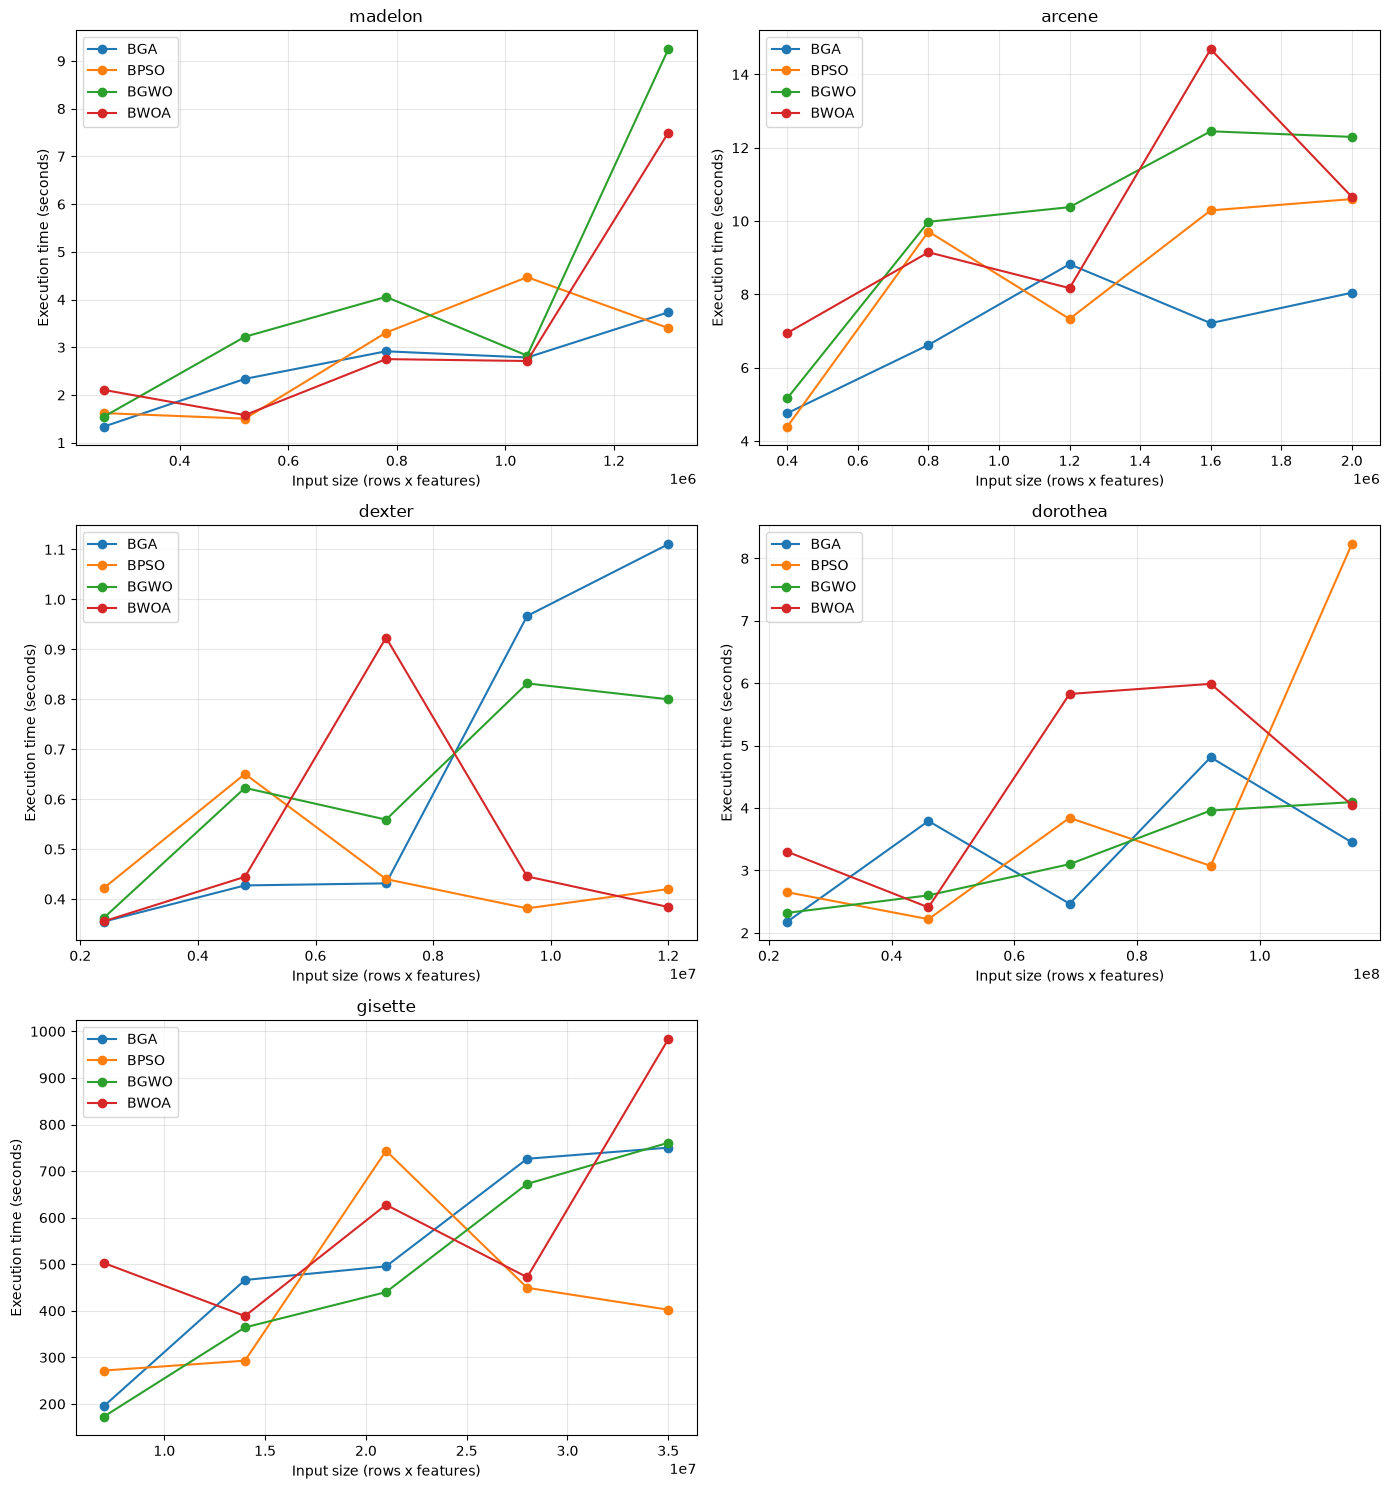

Saved plot: results\time_complexity_analysis\execution_time_vs_input_size_by_dataset.png


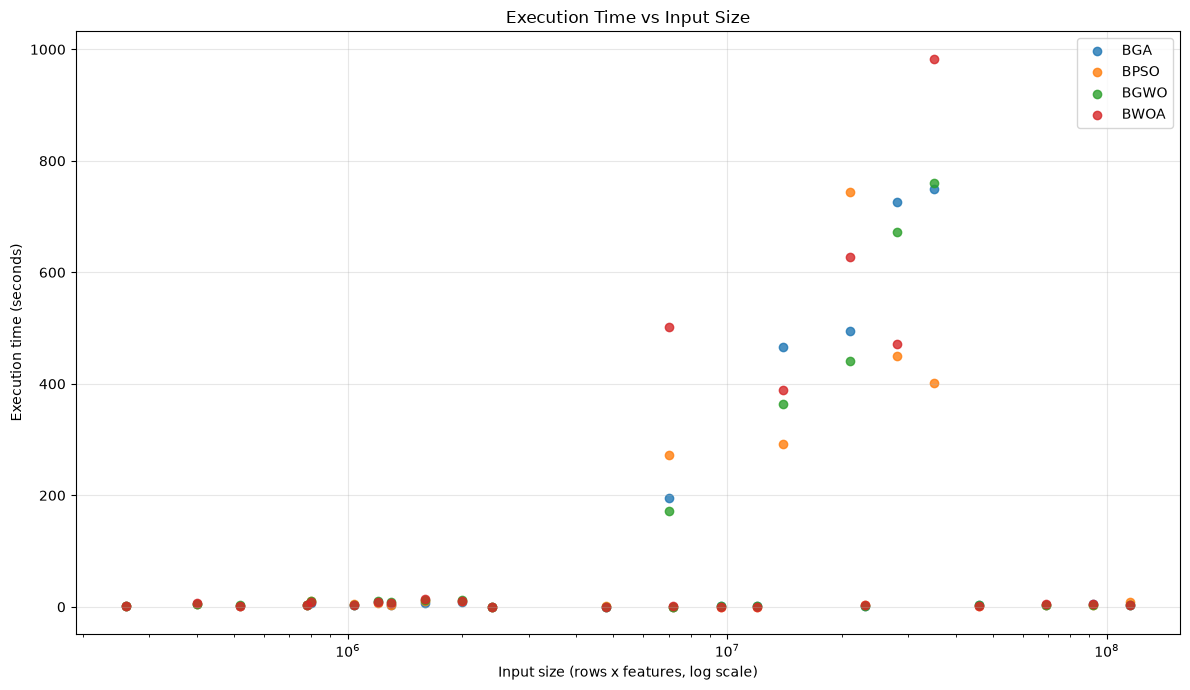

Saved plot: results\time_complexity_analysis\execution_time_vs_input_size_combined.png


In [12]:
def load_saved_scalability_results() -> pd.DataFrame:
    result_files = sorted(RESULTS_DIR.glob("*_scalability_results.csv"))
    if not result_files:
        raise FileNotFoundError(f"No scalability result files found in {RESULTS_DIR}")
    combined = pd.concat((pd.read_csv(path) for path in result_files), ignore_index=True)
    combined.to_csv(RESULTS_DIR / "combined_scalability_results.csv", index=False)
    return combined


def plot_execution_time_by_dataset(results: pd.DataFrame) -> None:
    datasets = [name for name in DATASET_NAMES if name in set(results["dataset"])]
    if not datasets:
        raise ValueError("No dataset results available to plot.")

    column_count = 2
    row_count = int(np.ceil(len(datasets) / column_count))
    figure, axes = plt.subplots(row_count, column_count, figsize=(14, 5 * row_count), squeeze=False)
    axes_flat = axes.ravel()

    for axis_index, dataset_name in enumerate(datasets):
        axis = axes_flat[axis_index]
        dataset_results = results[results["dataset"] == dataset_name]
        for algorithm_name in ALGORITHMS:
            algorithm_results = dataset_results[dataset_results["algorithm"] == algorithm_name].sort_values("input_size")
            if algorithm_results.empty:
                continue
            axis.plot(
                algorithm_results["input_size"],
                algorithm_results["runtime_seconds"],
                marker="o",
                label=algorithm_name,
            )
        axis.set_title(dataset_name)
        axis.set_xlabel("Input size (rows x features)")
        axis.set_ylabel("Execution time (seconds)")
        axis.grid(True, alpha=0.3)
        axis.legend()

    for empty_axis in axes_flat[len(datasets):]:
        empty_axis.axis("off")

    figure.tight_layout()
    output_path = RESULTS_DIR / "execution_time_vs_input_size_by_dataset.png"
    figure.savefig(output_path, dpi=200)
    plt.show()
    print(f"Saved plot: {output_path}")


def plot_combined_execution_time(results: pd.DataFrame) -> None:
    figure, axis = plt.subplots(figsize=(12, 7))
    for algorithm_name in ALGORITHMS:
        algorithm_results = results[results["algorithm"] == algorithm_name].sort_values("input_size")
        if algorithm_results.empty:
            continue
        axis.scatter(
            algorithm_results["input_size"],
            algorithm_results["runtime_seconds"],
            label=algorithm_name,
            alpha=0.8,
        )
    axis.set_xscale("log")
    axis.set_xlabel("Input size (rows x features, log scale)")
    axis.set_ylabel("Execution time (seconds)")
    axis.set_title("Execution Time vs Input Size")
    axis.grid(True, alpha=0.3)
    axis.legend()
    figure.tight_layout()
    output_path = RESULTS_DIR / "execution_time_vs_input_size_combined.png"
    figure.savefig(output_path, dpi=200)
    plt.show()
    print(f"Saved plot: {output_path}")


combined_results = load_saved_scalability_results()
display(combined_results)
plot_execution_time_by_dataset(combined_results)
plot_combined_execution_time(combined_results)
